# Project 02: Visual Word Recognition & Morphological Processing
**Replicating Masked Morphological Priming Analysis using Linear Mixed-Effects Models (LMM)**

## 1. Project Objective
This project simulates and analyzes behavioral data from a **Masked Priming Lexical Decision Task (LDT)**, directly inspired by the core paradigms used in visual word recognition and reading development research (e.g., Beyersmann et al.). 

The analysis transitions from traditional repeated-measures ANOVA to **Linear Mixed-Effects Models (LMM)** in Python. This approach rigorously controls for crossed random effects (Subjects and Items), reflecting the current gold standard in modern psycholinguistics.

**Experimental Conditions (Target - Prime):**
1.  **Morphological:** e.g., *farmer* - *farm* (Form & Meaning overlap)
2.  **Orthographic (Pseudo-morphological):** e.g., *corner* - *corn* (Form overlap only)
3.  **Unrelated (Control):** e.g., *spinach* - *farm* (No overlap)

**Hypothesis:** Morphological priming will yield significantly faster Reaction Times (RTs) compared to both Orthographic and Unrelated conditions.

## 2. Technical Stack
*   **Data Manipulation:** `pandas`, `numpy`
*   **Statistical Modeling:** `statsmodels` (Linear Mixed-Effects Models)
*   **Visualization:** `seaborn`, `matplotlib`

## 3. References (Target Paradigms)
*   **Beyersmann, E., Castles, A., & Coltheart, M. (2012).** Morphological processing during visual word recognition in developing readers: Evidence from masked priming. *The Quarterly Journal of Experimental Psychology*, 65(7), 1306-1326.
*   **Beyersmann, E., Ziegler, J. C., Castles, A., Coltheart, M., Kezilas, Y., & Grainger, J. (2016).** Morpho-orthographic segmentation without semantics. *Psychonomic Bulletin & Review*, 23(2), 533-539.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# Visualization Settings
sns.set_theme(style="ticks")
plt.rcParams['axes.unicode_minus'] = False

# 1. Synthetic Experimental Data Generation (Masked Priming LDT)
np.random.seed(42)

n_subjects = 40       # 40 Participants
n_items_per_cond = 30 # 30 Words per condition
conditions = ['Morphological', 'Orthographic', 'Unrelated']

data = []
base_rt = 650 # Average baseline RT in milliseconds

# True effects we want to simulate (Morphological is 40ms faster)
fixed_effects = {'Morphological': -40, 'Orthographic': -10, 'Unrelated': 0}

# Simulating Random Effects
# Some subjects are naturally faster/slower (SD = 50ms)
subj_intercepts = np.random.normal(0, 50, n_subjects) 
# Some words are naturally harder/easier to read (SD = 30ms)
item_intercepts = {cond: np.random.normal(0, 30, n_items_per_cond) for cond in conditions} 

for subj in range(n_subjects):
    for cond in conditions:
        for item in range(n_items_per_cond):
            # RT = Base + Condition Effect + Subject Random Effect + Item Random Effect + Residual Noise
            residual_noise = np.random.normal(0, 40)
            rt = base_rt + fixed_effects[cond] + subj_intercepts[subj] + item_intercepts[cond][item] + residual_noise
            
            data.append({
                'Subject': f'S{subj+1:03d}',
                'Condition': cond,
                'Item': f'Item_{cond}_{item+1:02d}',
                'RT': rt
            })
df_exp = pd.DataFrame(data)

print(f"Generated LDT Dataset Shape: {df_exp.shape}")
print(df_exp.head())

Generated LDT Dataset Shape: (3600, 4)
  Subject      Condition                   Item          RT
0    S001  Morphological  Item_Morphological_01  594.963168
1    S001  Morphological  Item_Morphological_02  642.719275
2    S001  Morphological  Item_Morphological_03  588.874111
3    S001  Morphological  Item_Morphological_04  644.746294
4    S001  Morphological  Item_Morphological_05  553.703079


## 3. Data Preprocessing & Visualization
In typical reaction time analyses, it is crucial to handle outliers (e.g., RTs < 300ms or > 1500ms, or beyond 2.5 SDs).

Retained 3562 trials out of 3600 after outlier trimming.


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22736\3451161346.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Condition', y='RT', data=df_clean, inner="quartile", palette="muted")


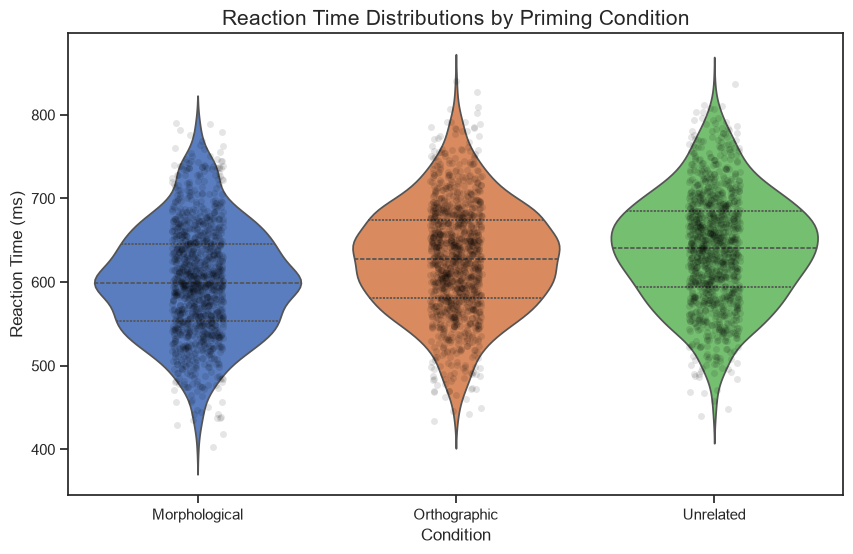

In [3]:
# 1. Outlier Trimming (Simulating standard psycholinguistic prep)
# Remove impossible RTs and extreme outliers (beyond 2.5 SD per subject)
df_clean = df_exp[(df_exp['RT'] > 300) & (df_exp['RT'] < 1500)].copy()
df_clean['RT_Z'] = df_clean.groupby('Subject')['RT'].transform(lambda x: (x - x.mean()) / x.std())
df_clean = df_clean[np.abs(df_clean['RT_Z']) < 2.5]

print(f"Retained {len(df_clean)} trials out of {len(df_exp)} after outlier trimming.")

# 2. Visualization: Raincloud/Violin plot for RT distributions
plt.figure(figsize=(10, 6))
sns.violinplot(x='Condition', y='RT', data=df_clean, inner="quartile", palette="muted")
sns.stripplot(x='Condition', y='RT', data=df_clean, color="black", alpha=0.1, jitter=True)
plt.title("Reaction Time Distributions by Priming Condition", fontsize=15)
plt.ylabel("Reaction Time (ms)", fontsize=12)
plt.xlabel("Condition", fontsize=12)
plt.show()

## 4. Linear Mixed-Effects Model (LMM) Analysis
Fitting an LMM to account for the fixed effect of `Condition` while controlling for the random variances introduced by different `Subjects`. 
*(Note: 'Unrelated' condition is set as the baseline reference).*

In [4]:
# Set 'Unrelated' as the baseline (reference) condition
df_clean['Condition'] = pd.Categorical(df_clean['Condition'], categories=['Unrelated', 'Orthographic', 'Morphological'], ordered=True)

# Fit Linear Mixed-Effects Model
# RT is predicted by Condition, with random intercepts for Subjects
lmm_formula = "RT ~ C(Condition)"
model = smf.mixedlm(lmm_formula, df_clean, groups=df_clean["Subject"])
lmm_result = model.fit()

print("======================================================================")
print("             Linear Mixed-Effects Model Results (RT Analysis)         ")
print("======================================================================")
print(lmm_result.summary())
print("\n[Interpretation Summary]")
morph_pval = lmm_result.pvalues['C(Condition)[T.Morphological]']
ortho_pval = lmm_result.pvalues['C(Condition)[T.Orthographic]']

print(f"- Morphological vs Unrelated: p-value = {morph_pval:.4f}")
if morph_pval < 0.05:
    print("  -> Significant facilitation effect for Morphological priming.")
else:
    print("  -> No significant Morphological effect.")

print(f"- Orthographic vs Unrelated: p-value = {ortho_pval:.4f}")
print("======================================================================")

             Linear Mixed-Effects Model Results (RT Analysis)         
                    Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       RT         
No. Observations:         3562          Method:                   REML       
No. Groups:               40            Scale:                    2213.0937  
Min. group size:          88            Log-Likelihood:           -18854.4533
Max. group size:          90            Converged:                Yes        
Mean group size:          89.0                                               
-----------------------------------------------------------------------------
                               Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------------------
Intercept                      640.668    7.584  84.480 0.000 625.805 655.532
C(Condition)[T.Orthographic]   -13.500    1.932  -6.988 0.000 -17.287  -9.714
C(Condition)[